In [148]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import mi_decoder
import matplotlib.pyplot as plt
import mne
from moabb.datasets import BNCI2014_001

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
dataset = BNCI2014_001()

data = dataset.get_data(subjects=[1])
# dataset.subject_list = dataset.subject_list[:2]


/Users/jakkolb/Desktop/Coding/GitHub/bci-iv-2a-decoding/.venv/lib/python3.10/site-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))
/Users/jakkolb/Desktop/Coding/GitHub/bci-iv-2a-decoding/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/42.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/Users/jakkolb/Desktop/Coding/GitHub/bci-iv-2a-decoding/.venv/lib/python3.10/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/43.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


In [169]:
print(type(dataset))
print(type(data))

print(data.keys())
print(data[1].keys())
print("0train keys: " + str(data[1]['0train'].keys()))
print("1test keys: " + str(data[1]['1test'].keys()))
print(data[1]['0train']['0'])
print(data[1]['1test']['0'])

raw = data[1]['1test']['0']
print(type(raw))






<class 'moabb.datasets.bnci.bnci_2014.BNCI2014_001'>
<class 'dict'>
dict_keys([1])
dict_keys(['0train', '1test'])
0train keys: dict_keys(['0', '1', '2', '3', '4', '5'])
1test keys: dict_keys(['0', '1', '2', '3', '4', '5'])
<RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>
<RawArray | 26 x 96735 (386.9 s), ~19.2 MiB, data loaded>
<class 'mne.io.array._array.RawArray'>


In [112]:
print(raw.info)
print(raw.info["lowpass"])
print(raw.ch_names)
print(type(raw.duration))

<Info | 11 non-empty values
 bads: []
 ch_names: Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, ...
 chs: 22 EEG, 3 EOG, 1 Stimulus
 custom_ref_applied: False
 description: Artifacts: 3/48 trials;
 dig: 25 items (3 Cardinal, 22 EEG)
 highpass: 0.0 Hz
 line_freq: 50.0
 lowpass: 125.0 Hz
 meas_date: 2008-01-01 00:00:00 UTC
 nchan: 26
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | birthday: 1986-01-01, sex: 2, hand: 1, his_id: sub-01>
>
125.0
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'EOG1', 'EOG2', 'EOG3', 'STI']
<class 'numpy.float64'>


In [126]:
signal = raw.get_data()
print(signal.shape)
print("Duration (seconds):", signal.shape[1] / raw.info['sfreq'])

events, event_id = mne.events_from_annotations(raw)
print("event_id mapping:", event_id)
print("events shape:", events.shape)
print("First 10 events:\n", events[:10])

print("Duration of event 1 (seconds):", (events[6][0] - events[5][0]) / raw.info['sfreq'])



(26, 96735)
Duration (seconds): 386.94
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
event_id mapping: {np.str_('feet'): 1, np.str_('left_hand'): 2, np.str_('right_hand'): 3, np.str_('tongue'): 4}
events shape: (48, 3)
First 10 events:
 [[  750     0     2]
 [ 2753     0     3]
 [ 4671     0     3]
 [ 6623     0     2]
 [ 8631     0     3]
 [10742     0     2]
 [12659     0     3]
 [14709     0     1]
 [16640     0     3]
 [18638     0     4]]
Duration of event 1 (seconds): 7.668


In [127]:
for class_name in ['feet', 'left_hand', 'right_hand', 'tongue']:
    code = event_id[class_name]
    count = np.sum(events[:, 2] == code)
    print(f"{class_name}: {count}, trials)")

feet: 12, trials)
left_hand: 12, trials)
right_hand: 12, trials)
tongue: 12, trials)


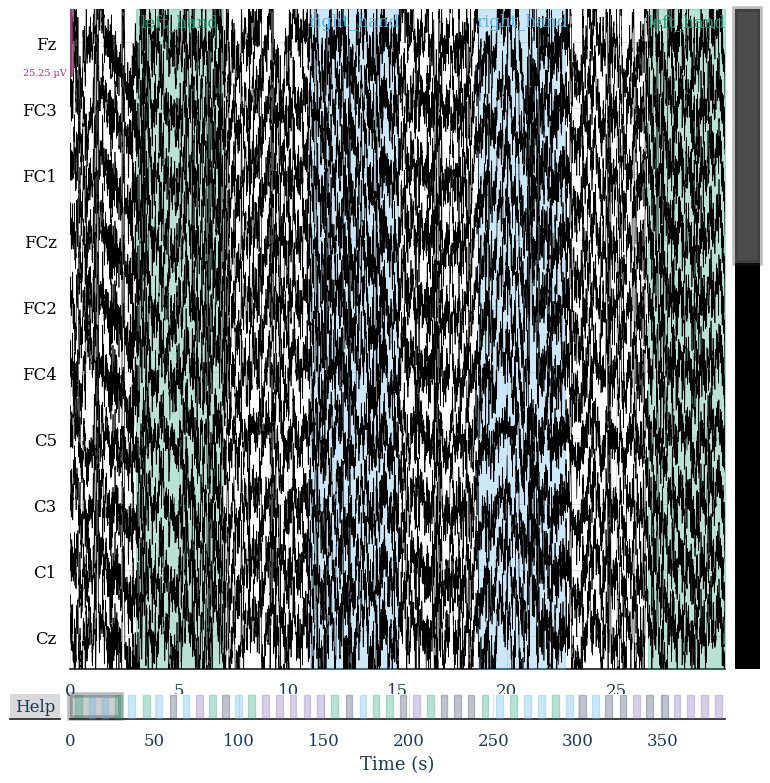

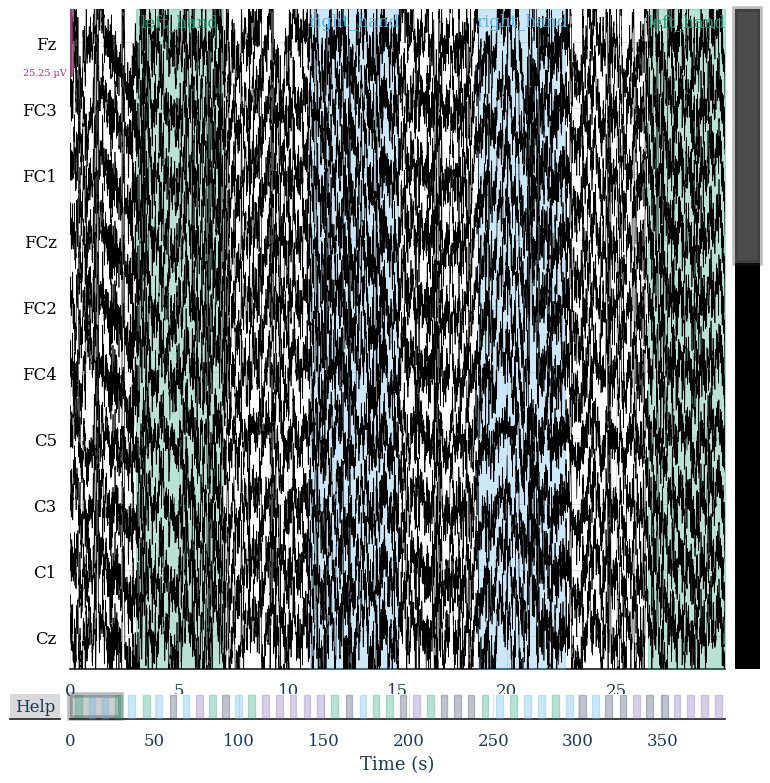

In [132]:
raw.plot(duration=30, n_channels=10, scalings='auto')

1.0 : 1.0)
9.012 : 2.0)
16.684 : 2.0)
24.492 : 1.0)
32.524 : 2.0)
40.968 : 1.0)
48.636 : 2.0)
56.836 : 3.0)
64.56 : 2.0)
72.552 : 4.0)
80.176 : 1.0)
87.756 : 3.0)
95.644 : 2.0)
103.42 : 1.0)
111.288 : 4.0)
119.768 : 4.0)
127.8 : 4.0)
136.064 : 4.0)
144.208 : 4.0)
152.472 : 1.0)
160.752 : 3.0)
169.072 : 2.0)
176.72 : 1.0)
184.844 : 1.0)
192.656 : 3.0)
200.5 : 4.0)
208.916 : 1.0)
216.932 : 3.0)
224.832 : 3.0)
232.936 : 3.0)
241.22 : 1.0)
249.648 : 2.0)
258.016 : 1.0)
266.38 : 2.0)
274.552 : 2.0)
282.808 : 1.0)
290.888 : 2.0)
298.776 : 3.0)
306.628 : 2.0)
314.328 : 3.0)
322.652 : 3.0)
330.564 : 4.0)
338.524 : 3.0)
347.0 : 3.0)
354.624 : 4.0)
362.336 : 4.0)
370.792 : 4.0)
379.028 : 4.0)


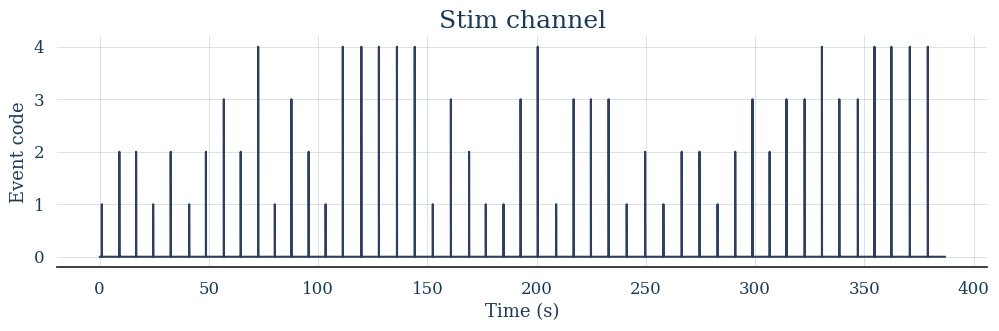

In [168]:

# print(data[1]['0train']['5'])
# print(signal1[25][2754])
stim = signal[25]
for i, sti in enumerate(stim):
    if sti != 0.0:
        print(f"{i / 250} : {sti})")
t = raw.times

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, stim)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Event code')
ax.set_title('Stim channel')
plt.show()

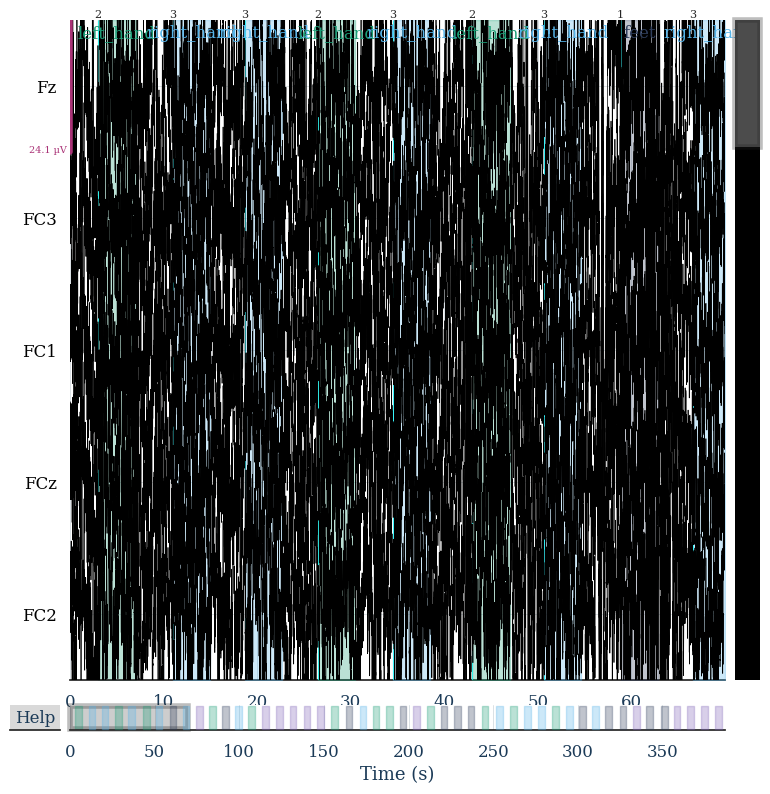

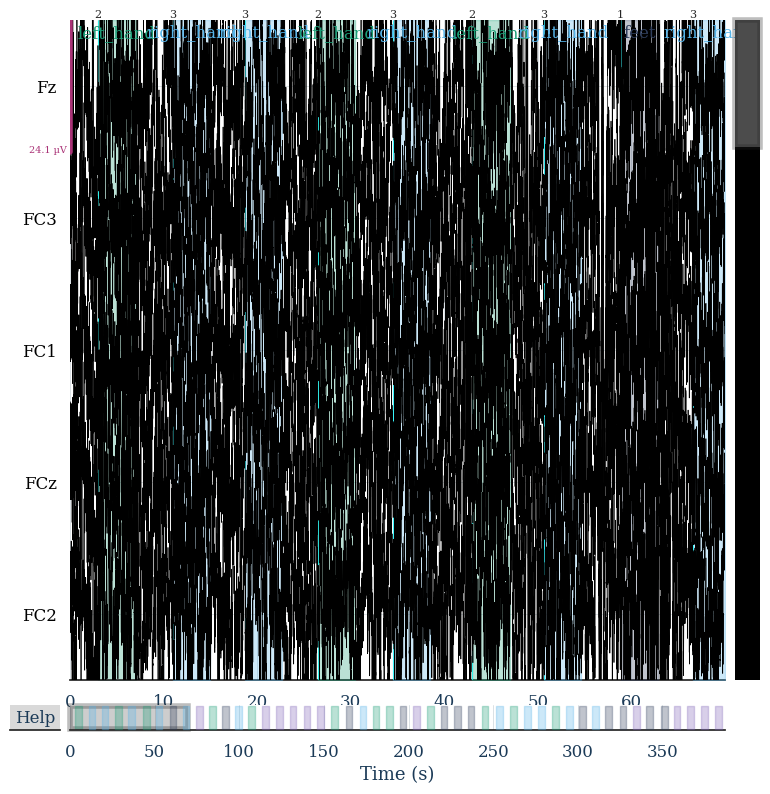

In [ ]:
raw.plot(duration=70, n_channels=5, events=events, scalings='auto')
